In [ ]:
!pip3 install pwntools 

In [2]:
from pwn import *
import base64

In [3]:
# Base64
data = bytes.fromhex('72bca9b68fc16ac7beeb8f849dca1d8a783e8acf9679bf9269f7bf')
base64.b64encode(data)

b'crypto/Base+64+Encoding+is+Web+Safe/'

In [ ]:
# Bytes and Big Integers
from Crypto.Util.number import long_to_bytes

 
print(long_to_bytes(11515195063862318899931685488813747395775516287289682636499965282714637259206269))

# above long_to_bytes function is same as folowing code, later we will use long_to_bytes frequently
data_hex = hex(11515195063862318899931685488813747395775516287289682636499965282714637259206269)
print(data_hex)
print(bytes.fromhex(data_hex[2:]))

b'crypto{3nc0d1n6_4ll_7h3_w4y_d0wn}'
0x63727970746f7b336e633064316e365f346c6c5f3768335f7734795f6430776e7d
b'crypto{3nc0d1n6_4ll_7h3_w4y_d0wn}'


In [2]:
# Encoding Challenge

import codecs
from pwn import * # pip install pwntools
from Crypto.Util.number import long_to_bytes
import json

r = remote("socket.cryptohack.org", 13377)

def json_send(hsh={}):
    if len(hsh) != 0:
        request = json.dumps(hsh).encode()
        r.sendline(request)
    line = r.readline()
    return json.loads(line.decode())

response = json_send()
while True:
    if "flag" in response:
        print(response["flag"])
        break
    encoding_type = response["type"]
    encoded = response["encoded"]

    if encoding_type == "base64":
        decoded = base64.b64decode(encoded).decode()
    elif encoding_type == "hex":
        decoded = bytes.fromhex(encoded).decode()
    elif encoding_type == "rot13":
        decoded = codecs.decode(encoded, "rot_13")
    elif encoding_type == "bigint":
        decoded = long_to_bytes(int(encoded, 16)).decode()
    elif encoding_type == "utf-8":
        decoded = "".join(chr(c) for c in encoded)

    print(decoded)
    response = json_send({"decoded": decoded})

[x] Opening connection to socket.cryptohack.org on port 13377
[x] Opening connection to socket.cryptohack.org on port 13377: Trying 134.122.111.232
[+] Opening connection to socket.cryptohack.org on port 13377: Done
reservations_paso_rule
miscellaneous_cumulative_prospect
dsl_collaborative_worth
it_len_trauma
boxes_discovered_mambo
logic_society_temporary
employee_dozens_worldwide
audience_pentium_specialist
she_para_instantly
wants_lifestyle_fighters
san_bath_touched
vampire_expenses_fitted
synthesis_designer_pursue
losing_quotes_feelings
database_rentals_surveys
was_leisure_quotations
printer_biol_theory
notice_exceptional_mba
tribes_armed_double
computational_possession_tobago
stunning_styles_improve
november_ecuador_controversial
formats_oracle_removable
creator_however_cheat
dividend_cheats_notre
disciplines_yacht_daisy
shows_availability_limit
enough_io_basement
exciting_disaster_motor
lot_those_syndrome
utah_recruitment_bought
japanese_owners_locally
williams_michelle_cambridge


In [12]:
# XOR Starter
label = b"label"
b"".join([bytes([int(b) ^ 13]) for b in label]) 

b'aloha'

In [ ]:
# XOR Properties

KEY1 = bytes.fromhex("a6c8b6733c9b22de7bc0253266a3867df55acde8635e19c73313")
KEY2_KEY1 = bytes.fromhex("37dcb292030faa90d07eec17e3b1c6d8daf94c35d4c9191a5e1e")
KEY2_KEY3 = bytes.fromhex("c1545756687e7573db23aa1c3452a098b71a7fbf0fddddde5fc1")
FLAG_KEY1_KEY3_KEY2 = bytes.fromhex("04ee9855208a2cd59091d04767ae47963170d1660df7f56f5faf")

KEY2 = xor(KEY2_KEY1, KEY1)
KEY3 = xor(KEY2_KEY3, KEY2)
FLAG = xor(FLAG_KEY1_KEY3_KEY2, KEY1, KEY3, KEY2)
print(FLAG)

b'crypto{x0r_i5_ass0c1at1v3}'


In [23]:
# Favourite byte

input_hex = "73626960647f6b206821204f21254f7d694f7624662065622127234f726927756d"
input_bytes = bytes.fromhex(input_hex)
for i in range(256):
    decoded_bytes = b""
    for b in input_bytes:
        decoded_char = xor(b, i.to_bytes())
        decoded_bytes += decoded_char
        if decoded_char[0] < 32 or decoded_char[0] > 126: # non-printable ASCII chars
            decoded_bytes = b""
            break
    if decoded_bytes:
        print(i, chr(i), decoded_bytes)
# then realized that we can just check whether output starts with crypto{

1  b'rchae~j!i !N $N|hNw%g!dc &"Nsh&tl'
3  b'pajcg|h#k"#L"&L~jLu\'e#fa"$ Lqj$vn'
4  b"wfmd`{o$l%$K%!KymKr b$af%#'Kvm#qi"
5  b'vgleazn%m$%J$ JxlJs!c%`g$"&Jwl"ph'
6  b'udofbym&n\'&I\'#I{oIp"`&cd\'!%Ito!sk'
7  b'tengcxl\'o&\'H&"HznHq#a\'be& $Hun rj'
8 b'{jahlwc(`)(G)-GuaG~,n(mj)/+Gza/}e'
11  b'xibkot`+c*+D*.DvbD}/m+ni*,(Dyb,~f'
14  b'}lgnjqe.f/.A/+AsgAx*h.kl/)-A|g){c'
15  b'|mfokpd/g./@.*@rf@y+i/jm.(,@}f(zb'
16  b'crypto{0x10_15_my_f4v0ur173_by7e}'
17  b'bsxqunz1y01^04^lx^g5w1ts062^cx6d|'
19  b'`qzswlx3{23\\26\\nz\\e7u3vq240\\az4f~'
21  b'fw|uqj~5}45Z40Zh|Zc1s5pw426Zg|2`x'
24  b'kzqx|gs8p98W9=WeqWn<~8}z9?;Wjq?mu'
28  b'o~u|xcw<t=<S=9SauSj8z<y~=;?Snu;iq'
30  b'm|w~zau>v?>Q?;QcwQh:x>{|?9=Qlw9ks'


In [47]:
# You either know, XOR you don't

def decode_with_xor(data,secret_key):
    return "".join([ chr(data[i] ^ secret_key[i]) for i in range(len(secret_key))])

data_encoded = bytes.fromhex("0e0b213f26041e480b26217f27342e175d0e070a3c5b103e2526217f27342e175d0e077e263451150104")
# since we know that decoded data starts with "crypto{" then we can try to find begining of secret key
data_decoded = b"crypto{"
print("Begining of key:",decode_with_xor(data_encoded, data_decoded)) # prints 'myXORke'
secret_key = b"myXORkey"
print("Begining of decrypted data:", decode_with_xor(data_encoded, secret_key)) # prints 'crypto{1'+
# maybe key is repeated?
secret_key = b"myXORkeymyXORkey"
print("Begining of decrypted data:", decode_with_xor(data_encoded, secret_key))
secret_key = b"myXORkeymyXORkeymyXORkeymyXORkeymyXORkeymy"
print("Begining of decrypted data:", decode_with_xor(data_encoded, secret_key))

Begining of key: myXORke
Begining of decrypted data: crypto{1
Begining of decrypted data: crypto{1f_y0u_Kn
Begining of decrypted data: crypto{1f_y0u_Kn0w_En0uGH_y0u_Kn0w_1t_4ll}


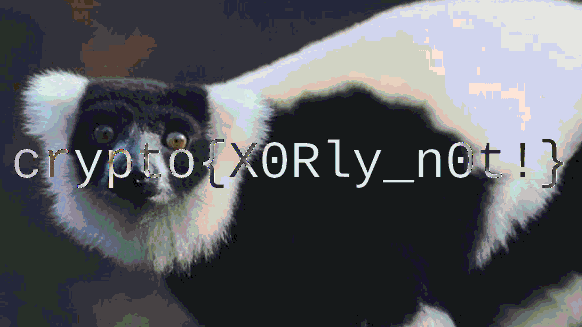

In [20]:
# Lemur XOR

from PIL import Image

lemur_file = Image.open("LemurXOR/lemur.png")
lemur = lemur_file.load()

flag_file = Image.open("LemurXOR/flag.png")
flag = flag_file.load()

width, height = lemur_file.size

for y in range(height):
    for x in range(width):
        lemur_pixel = lemur[x, y]
        flag_pixel = flag[x, y]
        new_pixel = tuple(flag_pixel[i] ^ lemur_pixel[i] for i in range(3))
        lemur[x, y] = new_pixel


display(lemur_file)

In [61]:
# Greatest Common Divisor

def euler_gcd(a, b):
    (a,b) = (max(a,b),min(a,b))
    if b == 0:
        return a
    reminder = a % b
    return euler_gcd(b, reminder)

print(euler_gcd(66528,52920))

1512


In [68]:
# Extended GCD

assert 1 == euler_gcd(26513, 32321)
# we need to find u,v such that 1 == 26513u + 32321v
# so two parts should give same reminder when divided by 26513
# hence 32321v % 26513 == 1

#TODO find fast way
for v in range(-26513,26513):
    if (32321 * v) % 26513 == 1:
        print("v:", v)
        u = (1 - 32321 * v) // 26513
        print("u:", u)
        print("_________________")



v: -8404
u: 10245
_________________
v: 18109
u: -22076
_________________


In [ ]:
# Modular Arithmetic 1
# to get smallest x or y such that 11 ≡ x %6 or 8146798528947 ≡ y %17 it is enough to calculate module
# we only need positive integers because in modular arithmetic we work inside finite field
assert 11 % 6 == 5 
assert 8146798528947 % 17 == 4

In [71]:
# Modular Arithmetic 2
assert 1 == euler_gcd(273246787654, 65537) 
# hence 273246787654^65536 mod 65537 should be 1


In [ ]:
# Modular Inverting
# 3d ≡ 1 %13 is same as 3d-1 ≡ 0 %13
# so we should find solution of one of the equations:
# 3d-1=13 or 3d-1=0 or 3d-1=-13
# hence d=-4, we work inside finite field so d=(-4)%13=9

In [10]:
# Privacy-Enhanced Mail?

from Crypto.PublicKey import RSA

with open(f'PrivacyEnhancedMail/privacy_enhanced_mail.pem') as f:
    key = RSA.importKey(f.read())
    print(f"d={key.d}")
    print(f"n={key.n}")
    print(f"e={key.e}")

d=15682700288056331364787171045819973654991149949197959929860861228180021707316851924456205543665565810892674190059831330231436970914474774562714945620519144389785158908994181951348846017432506464163564960993784254153395406799101314760033445065193429592512349952020982932218524462341002102063435489318813316464511621736943938440710470694912336237680219746204595128959161800595216366237538296447335375818871952520026993102148328897083547184286493241191505953601668858941129790966909236941127851370202421135897091086763569884760099112291072056970636380417349019579768748054760104838790424708988260443926906673795975104689
n=261246791921698893969309345948325863816571347216864089248968344850600905554477282439399710923494023320744544861458788543891435301413739337226538912900199066105777530226920772341403416563589592837651252312706430446965348679628057258255378956137863300087560845611712459567079822502272953780420764491761239469561136453183083583210540793109281550275003877498584563481271161657137517

In [ ]:
# SSH Keys

from pathlib import Path
import hashlib
import base64

def read_field(data, i=0):
    l = int.from_bytes(data[i:i+4], "big")
    start = i + 4
    return data[start:start + l], start + l

pub_path = Path("SSHKeys") / "bruce_rsa.pub"
pub_contents = pub_path.read_text().strip()

parts = pub_contents.split()
alg, key_b64 = parts[0], parts[1]
print("Algorithm:", alg)
key_bytes = base64.b64decode(key_b64)
idx = 0
# DER format
name_field, idx = read_field(key_bytes, idx)   # should be b"ssh-rsa"
e_field, idx = read_field(key_bytes, idx)      # public exponent
n_field, idx = read_field(key_bytes, idx)      # modulus

e = int.from_bytes(e_field, "big")
modulus = int.from_bytes(n_field, "big")

print("algorithm field:", name_field)
print("e (exponent):", e)
print("modulus :", modulus)

Algorithm: ssh-rsa
algorithm field: b'ssh-rsa'
e (exponent): 65537
modulus : 39314062729225234484361945998200930162414726581518015528450945185795078159906004596692596036452615329276111529849428408898987565320608948570451753001457658006334990054517388720813812670040698655573956385500411142061430854036072341092932863363935527568939846052143529887052586389794547365149973142236690759007838067153988803106959459451477551329190379738890751917859777978615572286781595388821535447177971004010964350623594741297556254538318824906035601344770432354332027089486152345369847158721133438127601028123231803915444960301636530469314147238513745548730365822823899048385976682865433374265816808177960387112284014432446551621993023520179649978666773171610140831167305358755212866318581027689610988512094009738993939649316050678560054109986318426730309010780084086496135381437999598036850415669645144898092119629845343223483944280109089843189404116989611507312043166706466769763619588285282298376107958431450482434929

In [15]:
# CERTainly not

from pathlib import Path
import hashlib
import base64

def read_field(data, i=0):
    l = int.from_bytes(data[i:i+4], "big")
    start = i + 4
    return data[start:start + l], start + l

pub_path = Path("CERTainlynot") / "2048b-rsa-example-cert.der"
key_bytes = pub_path.read_bytes()

key = RSA.importKey(key_bytes)
print(f"n={key.n}")
print(f"e={key.e}")

n=22825373692019530804306212864609512775374171823993708516509897631547513634635856375624003737068034549047677999310941837454378829351398302382629658264078775456838626207507725494030600516872852306191255492926495965536379271875310457319107936020730050476235278671528265817571433919561175665096171189758406136453987966255236963782666066962654678464950075923060327358691356632908606498231755963567382339010985222623205586923466405809217426670333410014429905146941652293366212903733630083016398810887356019977409467374742266276267137547021576874204809506045914964491063393800499167416471949021995447722415959979785959569497
e=65537
